## **Build a Binary Classification model using UMAP-clustered scaffolds**

### We will use the data obtained in the descriptor generator example, and we'll use cluster groups as cv splits. We have 20 clusters so we will use 5 splits, 4 clusters per group.

In [1]:
import pandas as pd
import numpy as np
from mlchem.ml.feature_selection import filters,wrappers
from mlchem.ml.preprocessing import scaling, undersampling, feature_transformation
from sklearn.model_selection import train_test_split, GroupKFold
from mlchem.metrics import get_geometric_S
from mlchem.helper import  generate_cartesian_product
from sklearn.linear_model import LogisticRegression
#from sklearn.svm import SVC
#from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import roc_auc_score, matthews_corrcoef as mcc
#from itertools import combinations
import joblib


In [2]:
df_desc_rdkit = pd.read_csv('../data/data_rdkit.csv',index_col='SMILES')
data = pd.read_csv('../data/data.csv')
df_desc_rdkit['CLASS'] = data.CLASS.values
cluster_indices = joblib.load('../data/cluster_indices.pkl')
df_desc_rdkit['CLUSTER'] = cluster_indices

C:\Users\Leonardo.Contreas\AppData\Local\Temp\ipykernel_21352\2332006416.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_desc_rdkit['CLASS'] = data.CLASS.values
C:\Users\Leonardo.Contreas\AppData\Local\Temp\ipykernel_21352\2332006416.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_desc_rdkit['CLUSTER'] = cluster_indices


In [3]:
df_desc_rdkit.head()

,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,HeavyAtomMolWt,ExactMolWt,NumValenceElectrons,...,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea,CLASS,CLUSTER
SMILES,,,,,,,,,,,,,,,,,,,,,
CO,7.000000,7.000000,1.000000,1.000000,0.385284,3.000000,32.042,28.010,32.026215,14,...,0,0,0,0,0,0,0,0,0,3
C=NCCC(CCO)CCCCOC(=O)C=O,10.509995,10.509995,0.170950,-0.812254,0.192921,11.823529,243.303,222.135,243.147058,98,...,0,0,0,0,0,0,1,0,0,7
CCC=C=NC#CCC=NCCC(CCO)CCCCOC(=O)C=O,10.666806,10.666806,0.156018,-0.822758,0.138151,11.120000,348.443,320.219,348.204907,138,...,0,0,0,0,0,0,1,0,0,7
C#CCCCCOCCC=C=NC#CCC=NCCC(CCO)CCCCOC(=O)C=O,10.726874,10.726874,0.142995,-0.829415,0.082425,11.000000,444.572,408.284,444.262422,176,...,0,1,0,0,0,0,3,0,0,7
O=CC(=O)OCCCCC(CCO)CCN=CCC#CN=C=CCCOCCCCC1=CCCC=C1,10.757642,10.757642,0.147038,-0.825632,0.065004,13.305556,498.664,456.328,498.309372,198,...,0,0,0,0,0,0,2,0,0,7


## Preprocess data and take care of class imbalance

In [4]:
# Leave 10% out for testing as a holdout set never to interfer with feature selection
# This set will have a representative structural distribution

train_set, test_set, y_train, y_test = train_test_split(
    df_desc_rdkit,
    list(df_desc_rdkit.CLASS.values),
    test_size=0.1,
    stratify=list(df_desc_rdkit.CLUSTER.values),
    random_state=1,
 )

# Logs appear in console output
undersampling.check_class_balance(y_train)
undersampling.check_class_balance(y_test)

2026-09-30 09:56:06,782 - mlchem.ml.preprocessing.undersampling - INFO - CLASS BALANCE [0]: 273 (0.51) [1]: 262 (0.49)
2026-09-30 09:56:06,790 - mlchem.ml.preprocessing.undersampling - INFO - CLASS BALANCE [1]: 33 (0.55) [0]: 27 (0.45)


#### Take care of imbalance if more extreme than 60/40

In [5]:
class_counts = train_set['CLASS'].value_counts()
majority_ratio = class_counts.max() / class_counts.sum()

if majority_ratio > 0.6:   # customise this
    train_set, test_set = undersampling.undersample(
        train_set=train_set,
        test_set=test_set,
        class_column='CLASS',
        desired_proportion_majority=0.6,
        add_dropped_to_test=True,
    )
else:
    print(f'Skipping undersampling: current majority proportion is {majority_ratio:.2%}.')

Skipping undersampling: current majority proportion is 51.03%.


### Add interaction terms to descriptors (degree=1 will change nothing)

In [6]:
train_set

,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,HeavyAtomMolWt,ExactMolWt,NumValenceElectrons,...,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea,CLASS,CLUSTER
SMILES,,,,,,,,,,,,,,,,,,,,,
CBCC(CCCCCC=O)C1CC=N[N+]CCC=CCC(C)C1C#COC(O)=CC,10.606952,10.606952,0.131211,-0.161665,0.129244,23.580645,427.418,387.098,427.312650,170,...,0,0,0,0,0,0,3,0,0,15
CCC(CC=CCCCCCCO)CCC=CCC=CNCN,8.718764,8.718764,0.336649,0.336649,0.220185,13.521739,322.537,284.233,322.298414,134,...,0,0,0,0,0,0,4,0,0,2
C=CCCCC[N+]C(C)CCCONCC=CCC(O)O,8.620495,8.620495,0.243550,-1.273910,0.186762,13.142857,299.435,268.187,299.232919,122,...,0,0,0,0,0,0,2,0,0,4
OCCC1=CCCN(O)CCCCC1,9.401856,9.401856,0.244715,0.244715,0.668015,21.714286,199.294,178.126,199.157229,82,...,0,0,0,0,0,0,0,0,0,3
CC(CCCC=CCCCCCCCCC#CC=CCNCCO)CCCCCCC=CCN,8.654281,8.654281,0.186501,0.186501,0.077552,12.676471,472.802,416.354,472.439264,196,...,0,0,0,0,0,0,12,0,0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
CNOCCCCOCC=CN,5.211485,5.211485,0.600580,0.600580,0.413085,11.083333,174.244,156.100,174.136828,72,...,0,0,0,0,0,0,1,0,1,6
B=C(NNCCCCC=C1CC1CCO)C1=C2CCCCCCOCCC1CCC2,8.974914,8.974914,0.326898,0.326898,0.218297,26.733333,414.443,371.099,414.341759,168,...,0,0,0,0,0,0,2,0,0,10
CCOCCC=NCCCNCCC=O,9.989846,9.989846,0.594866,0.594866,0.317635,11.000000,214.309,192.133,214.168128,88,...,0,0,0,0,0,0,0,0,1,4


In [7]:
degree = 1
train_set_poly = feature_transformation.polynomial_expansion(train_set.iloc[:,:-2],degree)
test_set_poly = feature_transformation.polynomial_expansion(test_set.iloc[:,:-2],degree)

train_set_poly['CLASS'] = train_set['CLASS']
test_set_poly['CLASS'] = test_set['CLASS']

In [8]:
train_set_poly

,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,HeavyAtomMolWt,ExactMolWt,NumValenceElectrons,...,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea,CLASS
SMILES,,,,,,,,,,,,,,,,,,,,,
CBCC(CCCCCC=O)C1CC=N[N+]CCC=CCC(C)C1C#COC(O)=CC,10.606952,10.606952,0.131211,-0.161665,0.129244,23.580645,427.418,387.098,427.312650,170.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,0.0,0
CCC(CC=CCCCCCCO)CCC=CCC=CNCN,8.718764,8.718764,0.336649,0.336649,0.220185,13.521739,322.537,284.233,322.298414,134.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,0.0,0
C=CCCCC[N+]C(C)CCCONCC=CCC(O)O,8.620495,8.620495,0.243550,-1.273910,0.186762,13.142857,299.435,268.187,299.232919,122.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,0
OCCC1=CCCN(O)CCCCC1,9.401856,9.401856,0.244715,0.244715,0.668015,21.714286,199.294,178.126,199.157229,82.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
CC(CCCC=CCCCCCCCCC#CC=CCNCCO)CCCCCCC=CCN,8.654281,8.654281,0.186501,0.186501,0.077552,12.676471,472.802,416.354,472.439264,196.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,12.0,0.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
CNOCCCCOCC=CN,5.211485,5.211485,0.600580,0.600580,0.413085,11.083333,174.244,156.100,174.136828,72.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1
B=C(NNCCCCC=C1CC1CCO)C1=C2CCCCCCOCCC1CCC2,8.974914,8.974914,0.326898,0.326898,0.218297,26.733333,414.443,371.099,414.341759,168.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,0
CCOCCC=NCCCNCCC=O,9.989846,9.989846,0.594866,0.594866,0.317635,11.000000,214.309,192.133,214.168128,88.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1


### Filter and scale data

#### filter

In [9]:
# for tutorial purposes, we set strict thresholds to have a sparser and quicker fitting process

multicollinearity_threshold = 0.5
diversity_threshold = 0.4

print(train_set_poly.shape)
train_set_poly_filter_1 = filters.diversity_filter(df=train_set_poly,
                                                   threshold=diversity_threshold,
                                                   target_variable='CLASS')
print(train_set_poly_filter_1.shape)


train_set_poly_filter_2 = filters.collinearity_filter(df=train_set_poly_filter_1,
                                                      threshold=multicollinearity_threshold,
                                                      target_variable='CLASS',
                                                      method='pearson',
                                                      numeric_only=False)
print(train_set_poly_filter_2.shape)

test_set_poly_filter_2 = test_set_poly[train_set_poly_filter_2.columns]
train_set_poly_filter_2

(535, 205)
(535, 94)
(535, 33)


,MaxAbsEStateIndex,MinEStateIndex,qed,SPS,FpDensityMorgan3,BalabanJ,HallKierAlpha,Kappa3,PEOE_VSA1,PEOE_VSA8,...,FractionCSP3,SMR_VSA1,SlogP_VSA2,fr_Imine,fr_NH0,fr_NH1,fr_aldehyde,fr_ether,fr_unbrch_alkane,CLASS
SMILES,,,,,,,,,,,,,,,,,,,,,
CBCC(CCCCCC=O)C1CC=N[N+]CCC=CCC(C)C1C#COC(O)=CC,10.606952,-0.161665,0.129244,23.580645,2.935484,3.101491,-1.995065,11.833657,14.637928,23.860957,...,0.680000,14.637928,31.431558,0.0,2.0,0.0,1.0,1.0,3.0,0
CCC(CC=CCCCCCCO)CCC=CCC=CNCN,8.718764,0.336649,0.220185,13.521739,2.478261,3.594027,-1.060000,17.131022,16.156983,6.606882,...,0.700000,5.106527,18.382101,0.0,0.0,1.0,0.0,0.0,4.0,0
C=CCCCC[N+]C(C)CCCONCC=CCC(O)O,8.620495,-1.273910,0.186762,13.142857,2.761905,3.224423,-0.720000,17.228288,15.050643,25.807221,...,0.750000,15.050643,42.241317,0.0,1.0,1.0,0.0,0.0,2.0,0
OCCC1=CCCN(O)CCCCC1,9.401856,0.244715,0.668015,21.714286,2.857143,2.400473,-0.380000,4.744529,10.313780,19.696395,...,0.818182,10.313780,35.073393,0.0,1.0,0.0,0.0,0.0,0.0,0
CC(CCCC=CCCCCCCCCC#CC=CCNCCO)CCCCCCC=CCN,8.654281,0.186501,0.077552,12.676471,2.029412,3.313399,-1.340000,28.692616,16.156983,26.055091,...,0.741935,5.106527,31.347679,0.0,0.0,1.0,0.0,0.0,12.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
CNOCCCCOCC=CN,5.211485,0.600580,0.413085,11.083333,2.750000,2.813864,-0.580000,9.420000,15.308119,13.654554,...,0.750000,9.574452,26.868318,0.0,0.0,1.0,0.0,1.0,1.0,1
B=C(NNCCCCC=C1CC1CCO)C1=C2CCCCCCOCCC1CCC2,8.974914,0.326898,0.218297,26.733333,2.833333,1.401280,-0.905065,7.976307,5.106527,0.000000,...,0.800000,9.843390,44.546911,0.0,0.0,2.0,0.0,1.0,2.0,0
CCOCCC=NCCCNCCC=O,9.989846,0.594866,0.317635,11.000000,2.933333,2.991108,-0.740000,13.260000,14.848189,38.752639,...,0.818182,9.531400,45.348794,1.0,1.0,1.0,1.0,1.0,0.0,1


In [10]:
(train_set_poly_filter_2.corr()**2)['CLASS'].to_frame().sort_values('CLASS',ascending=False).head()

,CLASS
CLASS,1.000000
MaxAbsEStateIndex,0.343926
MinEStateIndex,0.291383
SMR_VSA1,0.219808
EState_VSA2,0.216316


#### scale

In [11]:
train_set_scaled, train_scaler = scaling.scale_df_standard(
    train_set_poly_filter_2,
    columns_to_preserve=['CLASS'], # exclude CLASS from scaling and from returned dataframe
    skip_binary_columns=True,
 )
test_set_scaled = scaling.transform_df(
    test_set_poly_filter_2,
    train_scaler,
    columns_to_preserve=['CLASS'], # exclude CLASS from transformation and from returned dataframe
    skip_binary_columns=True,
 )[0]

y_train = train_set_poly.CLASS.values
y_test = test_set_poly.CLASS.values

In [12]:
train_set_scaled

,MaxAbsEStateIndex,MinEStateIndex,qed,SPS,FpDensityMorgan3,BalabanJ,HallKierAlpha,Kappa3,PEOE_VSA1,PEOE_VSA8,...,VSA_EState8,FractionCSP3,SMR_VSA1,SlogP_VSA2,fr_Imine,fr_NH0,fr_NH1,fr_ether,fr_unbrch_alkane,fr_aldehyde
SMILES,,,,,,,,,,,,,,,,,,,,,
CBCC(CCCCCC=O)C1CC=N[N+]CCC=CCC(C)C1C#COC(O)=CC,1.346258,-0.922987,-1.852773,1.423955,0.831346,0.805546,-2.848635,0.038534,1.600003,1.436968,...,1.323039,-0.110346,1.641901,0.685808,-0.503411,1.943246,-0.590204,1.155871,0.580823,1.0
CCC(CC=CCCCCCCO)CCC=CCC=CNCN,0.551503,-0.089574,-1.171257,-0.010486,-0.198907,1.681344,-0.996476,0.144708,1.901430,-0.354877,...,-0.121778,-0.021433,-0.191173,-0.164727,-0.503411,-0.695426,0.851619,-0.519985,0.995144,0.0
C=CCCCC[N+]C(C)CCCONCC=CCC(O)O,0.510141,-2.783179,-1.421729,-0.064516,0.440223,1.024136,-0.323010,0.146657,1.681898,1.639089,...,1.735303,0.200848,1.721274,1.390365,-0.503411,0.623910,0.851619,-0.519985,0.166503,0.0
OCCC1=CCCN(O)CCCCC1,0.839023,-0.243330,2.184795,1.157804,0.654822,-0.440961,0.350456,-0.103551,0.741961,1.004476,...,-0.639780,0.503960,0.810283,0.923175,-0.503411,0.623910,-0.590204,-0.519985,-0.662138,0.0
CC(CCCC=CCCCCCCCCC#CC=CCNCCO)CCCCCCC=CCN,0.524362,-0.340691,-2.240156,-0.131025,-1.210291,1.182349,-1.551094,0.376434,1.901430,1.664830,...,0.481678,0.164996,-0.191173,0.680341,-0.503411,-0.695426,0.851619,-0.519985,4.309708,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
CNOCCCCOCC=CN,-0.924740,0.351842,0.274341,-0.358212,0.413399,0.294106,-0.045701,-0.009842,1.732989,0.377028,...,-0.513012,0.200848,0.668096,0.388386,-0.503411,-0.695426,0.851619,1.155871,-0.247818,0.0
B=C(NNCCCCC=C1CC1CCO)C1=C2CCCCCCOCCC1CCC2,0.659319,-0.105883,-1.185406,1.873541,0.601172,-2.217667,-0.689583,-0.038777,-0.291317,-1.041005,...,-0.125210,0.423130,0.719818,1.540638,-0.503411,-0.695426,2.293442,1.155871,0.166503,0.0
CCOCCC=NCCCNCCC=O,1.086513,0.342285,-0.440965,-0.370096,0.826501,0.609270,-0.362626,0.067122,1.641725,2.983477,...,0.998365,0.503960,0.659816,1.592903,1.506476,0.623910,0.851619,1.155871,-0.662138,1.0


In [13]:
groupkfold = GroupKFold(n_splits=5, shuffle=True, random_state=1)
splits = list(groupkfold.split(train_set, train_set['CLASS'], groups=train_set.CLUSTER))

In [14]:
display(len(splits))
splits[0][0].shape, splits[0][1].shape

5

((422,), (113,))

## Modelling - explore wrappers (*Sequential Feature Selection* and *Combinatorial Selection*)

### Sequential Feature Selection

In [15]:
SFS = wrappers.SequentialForwardSelection
estimator = LogisticRegression(l1_ratio=1, C=1, solver='liblinear', random_state=1)
sfs = SFS(
    estimator=estimator,
    estimator_string='Logistic Regression simple model',
    metric=roc_auc_score,
    max_features=20,
    logic='greater',
    task_type='classification',
    cv_indices=splits,
    desired_performance_score='cv',
    log_level='INFO',
)

sfs.fit(
    train_set=train_set_scaled,
    test_set=test_set_scaled,
    y_train=y_train,
    y_test=y_test,
    n_jobs=-1
 )

2026-09-30 09:56:13,386 - mlchem.ml.feature_selection.wrappers - INFO - SFS start: samples=535, features=32, max_features=20, cv_iter=5, n_jobs=12
SFS: 100%|██████████| 20/20 [00:44<00:00,  2.22s/it]
2026-09-30 09:56:57,854 - mlchem.ml.feature_selection.wrappers - INFO - SFS completed: selected_features=20


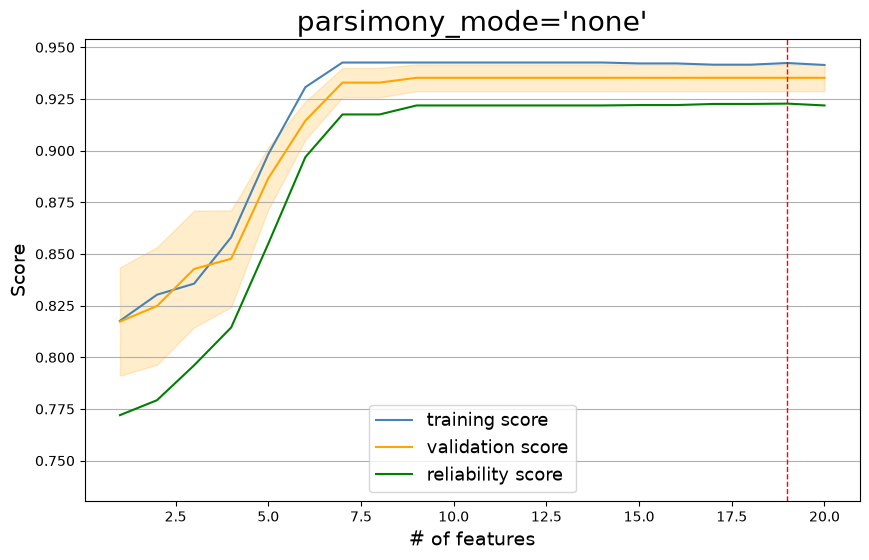

2026-09-30 09:57:53,792 - mlchem.ml.feature_selection.wrappers - INFO - SFS summary: number_of_features=19
2026-09-30 09:57:53,802 - mlchem.ml.feature_selection.wrappers - INFO - SFS summary: winner_subset=['MinEStateIndex', 'HallKierAlpha', 'SMR_VSA1', 'fr_ether', 'VSA_EState2', 'fr_Imine', 'MaxAbsEStateIndex', 'FpDensityMorgan3', 'EState_VSA2', 'Kappa3', 'PEOE_VSA8', 'PEOE_VSA9', 'SMR_VSA7', 'SlogP_VSA4', 'EState_VSA6', 'EState_VSA9', 'fr_NH1', 'fr_unbrch_alkane', 'fr_aldehyde']
2026-09-30 09:57:53,802 - mlchem.ml.feature_selection.wrappers - INFO - SFS summary: train_score=0.942 ± 0.001
2026-09-30 09:57:53,802 - mlchem.ml.feature_selection.wrappers - INFO - SFS summary: cv_score=0.935 ± 0.006
2026-09-30 09:57:53,802 - mlchem.ml.feature_selection.wrappers - INFO - SFS summary: reliability_score=0.923 ± 0.008


array([0.95860806, 0.93023256, 0.91454545, 0.94117647, 0.93157895])

In [16]:
parsimony_none = sfs.find_best(which=None,
              parsimony_mode='none')
sfs.plot(best_feature=parsimony_none['best_index'], title="parsimony_mode='none'",alphas=[0,0.2,0.])
display(sfs.cv_folds[parsimony_none['best_index']-1])

2026-09-30 09:58:01,708 - mlchem.ml.feature_selection.wrappers - INFO - SFS parsimony: mode=standard_error | reference_k*=19 | selected_k=9


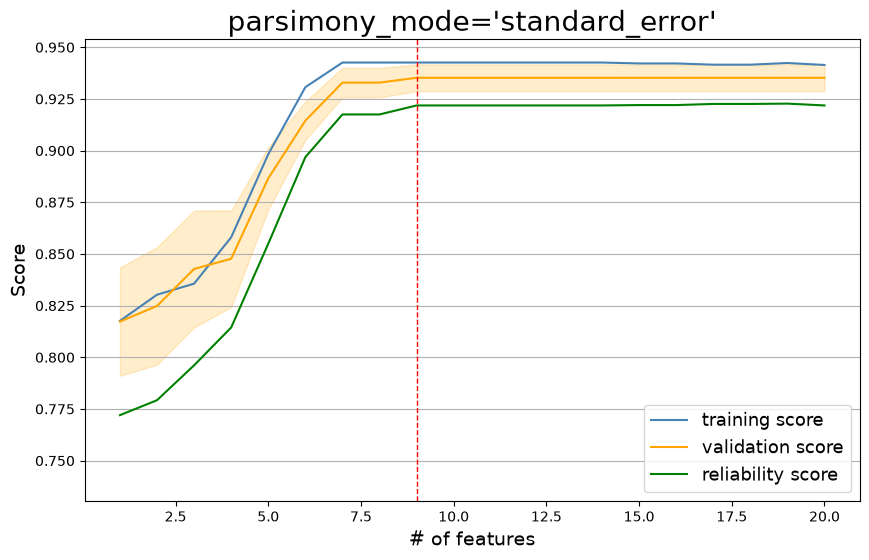

2026-09-30 09:58:02,182 - mlchem.ml.feature_selection.wrappers - INFO - SFS summary: number_of_features=9
2026-09-30 09:58:02,182 - mlchem.ml.feature_selection.wrappers - INFO - SFS summary: winner_subset=['MinEStateIndex', 'HallKierAlpha', 'SMR_VSA1', 'fr_ether', 'VSA_EState2', 'fr_Imine', 'MaxAbsEStateIndex', 'FpDensityMorgan3', 'EState_VSA2']
2026-09-30 09:58:02,198 - mlchem.ml.feature_selection.wrappers - INFO - SFS summary: train_score=0.943 ± 0.001
2026-09-30 09:58:02,198 - mlchem.ml.feature_selection.wrappers - INFO - SFS summary: cv_score=0.935 ± 0.006
2026-09-30 09:58:02,199 - mlchem.ml.feature_selection.wrappers - INFO - SFS summary: reliability_score=0.922 ± 0.008


array([0.95860806, 0.93023256, 0.91454545, 0.94117647, 0.93157895])

In [17]:
parsimony_standard_error = sfs.find_best(which=None,
              parsimony_mode='standard_error')
sfs.plot(best_feature=parsimony_standard_error['best_index'], title="parsimony_mode='standard_error'",alphas=[0,0.2,0])
display(sfs.cv_folds[parsimony_standard_error['best_index']-1])

In [22]:
from mlchem.ml.feature_selection.wrappers import _compute_fold_degradation

reference_k = parsimony_none['best_index']
candidate_k = parsimony_standard_error['best_index']

diagnostic = _compute_fold_degradation(
    sfs.cv_folds[reference_k - 1],
    sfs.cv_folds[candidate_k - 1],
)

print(f"Reference k*: {reference_k}")
print(f"Candidate k: {candidate_k}")
print(f"Fold-wise degradation: {diagnostic['degradation']}")
print(f"Mean degradation: {diagnostic['mean_degradation']}")
print(f"Standard error of degradation: {diagnostic['se_degradation']}")
print(f"Passes standard-error rule: {diagnostic['mean_degradation'] <= diagnostic['se_degradation']}")

# Show the full acceptance table against the same k* reference used by the selector.
for k in range(candidate_k-1, reference_k):
    candidate_diag = _compute_fold_degradation(
        sfs.cv_folds[reference_k - 1],
        sfs.cv_folds[k - 1],
    )
    print(
        f"k={k}: mean={candidate_diag['mean_degradation']:.6f}, "
        f"se={candidate_diag['se_degradation']:.6f}, "
        f"accepted={candidate_diag['mean_degradation'] <= candidate_diag['se_degradation']}"
    )

Reference k*: 19
Candidate k: 9
Fold-wise degradation: [0. 0. 0. 0. 0.]
Mean degradation: 0.0
Standard error of degradation: 0.0
Passes standard-error rule: True
k=8: mean=0.002326, se=0.002326, accepted=False
k=9: mean=0.000000, se=0.000000, accepted=True
k=10: mean=0.000000, se=0.000000, accepted=True
k=11: mean=0.000000, se=0.000000, accepted=True
k=12: mean=0.000000, se=0.000000, accepted=True
k=13: mean=0.000000, se=0.000000, accepted=True
k=14: mean=0.000000, se=0.000000, accepted=True
k=15: mean=0.000000, se=0.000000, accepted=True
k=16: mean=0.000000, se=0.000000, accepted=True
k=17: mean=0.000000, se=0.000000, accepted=True
k=18: mean=0.000000, se=0.000000, accepted=True


In [38]:
diagnostic

{'degradation': array([0., 0., 0., 0., 0.]),
 'mean_degradation': 0.0,
 'se_degradation': 0.0}

In [33]:
sfs.cv_folds[9-1]

array([0.95860806, 0.93023256, 0.91454545, 0.94117647, 0.93157895])

In [31]:
sfs.cv_folds[9-2]

array([0.95860806, 0.91860465, 0.91454545, 0.94117647, 0.93157895])

In [36]:
(sfs.cv_folds[9-1]-sfs.cv_folds[9-2]).std()/np.sqrt(5)

np.float64(0.002080063234883509)

### Combinatorial Selection

In [21]:
COMB = wrappers.CombinatorialSelection
comb = COMB(estimator=estimator,metric=get_geometric_S,logic='greater',
            task_type='classification',cv_indices=splits)

print('COMBINATORIAL STAGE 1 - COARSE SEARCH')
results_1 = comb.fit_stage_1(train_set=train_set_scaled,
                             test_set=test_set_scaled,
                             y_train=y_train,
                             y_test=y_test,
                             features=train_set_scaled.columns,
                             k=2,
                             training_threshold=0.7,
                             max_subsets=None,
                             ranking_target=y_train,
                             top_ranked_features=15,
                             cv_train_ratio=0.8,
                             cv_iter=None,
                             n_jobs=-1,)
display(results_1.head())
print('COMBINATORIAL STAGE 2 - FINE SEARCH')
results_2 = comb.fit_stage_2(top_n_subsets=5,cv_iter=None,n_jobs=-1)
display(results_2.head())

2026-09-29 20:14:57,230 - mlchem.ml.feature_selection.wrappers - INFO - Combinatorial stage 1 start: samples=535, features=32, k=2, n_jobs=12


COMBINATORIAL STAGE 1 - COARSE SEARCH


Stage 1: 100%|██████████| 120/120 [00:06<00:00, 19.31it/s]
2026-09-29 20:15:04,489 - mlchem.ml.feature_selection.wrappers - INFO - Combinatorial stage 1 completed: kept_subsets=47


,feature_subsets,training_score,cv_score,reliability_score,training_se,cv_se,reliability_se
33,"[MinEStateIndex, qed]",0.819184,0.815832,0.779147,0.002886,0.025426,0.019665
12,"[EState_VSA9, MinEStateIndex]",0.819634,0.807554,0.774384,0.008479,0.025231,0.019628
30,"[MinEStateIndex, Kappa3]",0.821016,0.807309,0.773059,0.006758,0.026430,0.020481
34,"[MinEStateIndex, VSA_EState8]",0.817151,0.813506,0.769037,0.007645,0.026126,0.019667
40,"[MinEStateIndex, SMR_VSA10]",0.816129,0.796220,0.768627,0.003191,0.025341,0.022503


2026-09-29 20:15:04,516 - mlchem.ml.feature_selection.wrappers - INFO - Combinatorial stage 2 start: recurrent_features=6, subset_size=5, n_jobs=12


COMBINATORIAL STAGE 2 - FINE SEARCH


Stage 1: 100%|██████████| 62/62 [00:03<00:00, 18.67it/s] 
2026-09-29 20:15:08,066 - mlchem.ml.feature_selection.wrappers - INFO - Combinatorial stage 2 completed: kept_subsets=31


,feature_subsets,training_score,cv_score,reliability_score,training_se,cv_se,reliability_se
28,"[EState_VSA9, Kappa3, MinEStateIndex, VSA_ESta...",0.846413,0.824975,0.787901,0.004155,0.028334,0.019924
12,"[Kappa3, MinEStateIndex, qed]",0.826649,0.807342,0.781044,0.002865,0.024565,0.020178
4,"[MinEStateIndex, qed]",0.819184,0.815832,0.779147,0.002886,0.025426,0.019665
23,"[EState_VSA9, MinEStateIndex, VSA_EState8, qed]",0.833368,0.825275,0.777833,0.004286,0.028440,0.019290
18,"[EState_VSA9, Kappa3, MinEStateIndex, qed]",0.838757,0.821563,0.777729,0.004949,0.033415,0.023774


## **Modelling** - try a different learning algorithm *and* different hyperparameter combinations

### For both SFS and COMB, automatically save best model and associated features

In [22]:
joblib.dump(train_set,'../data/train_set_rdkit')
joblib.dump(test_set,'../data/test_set_rdkit')

['../data/test_set_rdkit']

In [23]:
# both methods
cv_iter = 0     # crossvalidation iterations
cv_indices = splits  # crossvalidation split indices have the priority over cv_iter, cv_splitter and groups
n_jobs=-1

# sfs parameters
max_features = 10    # max features to include in sequential forward selection

# combinatorial selection parameters
top_ranked_features = 10     # number of top ranked features to consider in combinatorial selection.
                             # Ranking is computed based on mutual information with the target variable minus a penalty for correlation with other features.
                             # This is done to promote diversity in the selected features.
training_threshold = 0.75    # minimum accepted training score for a model to be considered valid in combinatorial selection further stages
cv_train_ratio = 0.8     # maximum tolerated ratio between training and test scores for a model to be considered valid in combinatorial selection
top_n_subsets = 5     # number of top ranked subsets to consider in combinatorial selection
k = 3     # number of features to include in each subset for combinatorial selection



### K Nearest Neighbours

2026-09-30 08:21:20,917 - mlchem.ml.feature_selection.wrappers - INFO - SFS start: samples=535, features=32, max_features=10, cv_iter=0, n_jobs=1



KNN_3




SFS: 100%|██████████| 10/10 [01:39<00:00,  9.93s/it]
2026-09-30 08:23:00,246 - mlchem.ml.feature_selection.wrappers - INFO - SFS completed: selected_features=10
2026-09-30 08:23:00,261 - mlchem.ml.feature_selection.wrappers - INFO - SFS parsimony: mode=uncertainty | reference_k*=2 | selected_k=1


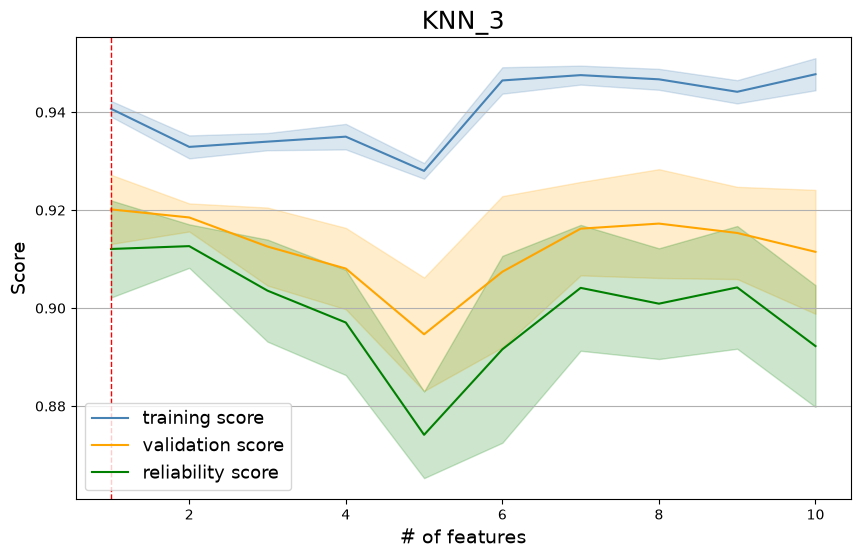

2026-09-30 08:23:04,937 - mlchem.ml.feature_selection.wrappers - INFO - SFS summary: number_of_features=1
2026-09-30 08:23:04,946 - mlchem.ml.feature_selection.wrappers - INFO - SFS summary: winner_subset=['SMR_VSA1']
2026-09-30 08:23:04,948 - mlchem.ml.feature_selection.wrappers - INFO - SFS summary: train_score=0.940700907429612 ± 0.0016062072996634686
2026-09-30 08:23:04,954 - mlchem.ml.feature_selection.wrappers - INFO - SFS summary: cv_score=0.9201532447920237 ± 0.007067098988710862
2026-09-30 08:23:04,959 - mlchem.ml.feature_selection.wrappers - INFO - SFS summary: reliability_score=0.9120701951218946 ± 0.009920302762612049
2026-09-30 08:23:04,979 - mlchem.ml.feature_selection.wrappers - INFO - Combinatorial stage 1 start: samples=535, features=32, k=3, n_jobs=12






-------------




COMBINATORIAL STAGE 1 - COARSE SEARCH


Stage 1: 100%|██████████| 175/175 [01:00<00:00,  2.88it/s]
2026-09-30 08:24:07,907 - mlchem.ml.feature_selection.wrappers - INFO - Combinatorial stage 1 completed: kept_subsets=169


,feature_subsets,training_score,cv_score,reliability_score,training_se,cv_se,reliability_se
0,[SMR_VSA1],0.940701,0.920153,0.912070,0.001606,0.007067,0.009920
12,"[SMR_VSA1, Kappa3]",0.940099,0.901500,0.887887,0.001882,0.015035,0.019233
15,"[SMR_VSA1, SlogP_VSA2]",0.945062,0.898507,0.881738,0.001353,0.012275,0.015967
3,"[SMR_VSA1, PEOE_VSA1]",0.941407,0.896495,0.879913,0.001763,0.007928,0.010598
10,"[SMR_VSA1, EState_VSA2]",0.946649,0.895452,0.877517,0.003205,0.013911,0.017930


2026-09-30 08:24:08,029 - mlchem.ml.feature_selection.wrappers - INFO - Combinatorial stage 2 start: recurrent_features=5, subset_size=5, n_jobs=12


...

Stage 1: 100%|██████████| 31/31 [00:01<00:00, 16.12it/s]
2026-09-30 08:24:10,192 - mlchem.ml.feature_selection.wrappers - INFO - Combinatorial stage 2 completed: kept_subsets=6


,feature_subsets,training_score,cv_score,reliability_score,training_se,cv_se,reliability_se
0,[SMR_VSA1],0.940701,0.920153,0.912070,0.001606,0.007067,0.009920
2,"[Kappa3, SMR_VSA1]",0.940099,0.901500,0.887887,0.001882,0.015035,0.019233
4,"[SMR_VSA1, SlogP_VSA2]",0.945062,0.898507,0.881738,0.001353,0.012275,0.015967
3,"[PEOE_VSA1, SMR_VSA1]",0.941407,0.896495,0.879913,0.001763,0.007928,0.010598
1,"[EState_VSA2, SMR_VSA1]",0.946649,0.895452,0.877517,0.003205,0.013911,0.017930


2026-09-30 08:24:10,325 - mlchem.ml.feature_selection.wrappers - INFO - SFS start: samples=535, features=32, max_features=10, cv_iter=0, n_jobs=1



KNN_5




SFS: 100%|██████████| 10/10 [00:56<00:00,  5.69s/it]
2026-09-30 08:25:07,220 - mlchem.ml.feature_selection.wrappers - INFO - SFS completed: selected_features=10
2026-09-30 08:25:07,221 - mlchem.ml.feature_selection.wrappers - INFO - SFS parsimony: mode=uncertainty | reference_k*=1 | selected_k=1


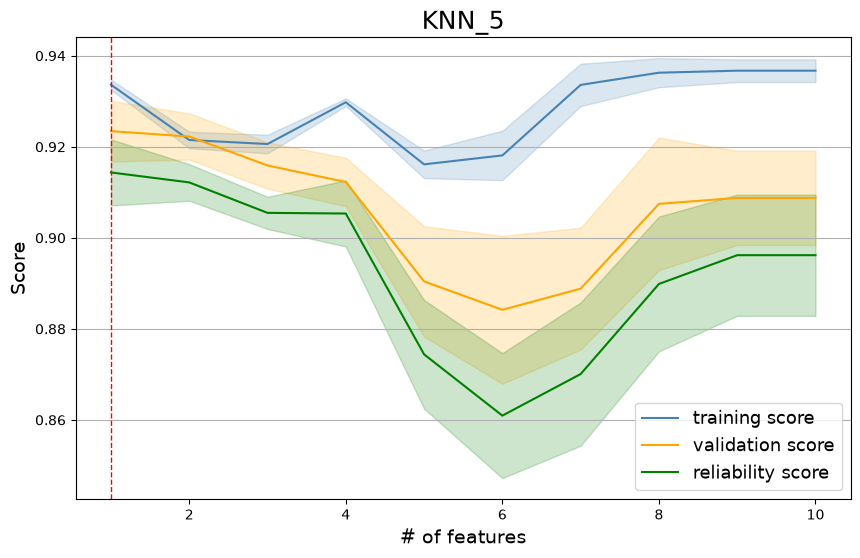

2026-09-30 08:25:07,986 - mlchem.ml.feature_selection.wrappers - INFO - SFS summary: number_of_features=1
2026-09-30 08:25:07,988 - mlchem.ml.feature_selection.wrappers - INFO - SFS summary: winner_subset=['SMR_VSA1']
2026-09-30 08:25:07,992 - mlchem.ml.feature_selection.wrappers - INFO - SFS summary: train_score=0.9336407686907602 ± 0.0011234850056128737
2026-09-30 08:25:07,993 - mlchem.ml.feature_selection.wrappers - INFO - SFS summary: cv_score=0.9234352960740748 ± 0.00667063766954362
2026-09-30 08:25:07,996 - mlchem.ml.feature_selection.wrappers - INFO - SFS summary: reliability_score=0.9143608594502382 ± 0.007267334580989612
2026-09-30 08:25:08,005 - mlchem.ml.feature_selection.wrappers - INFO - Combinatorial stage 1 start: samples=535, features=32, k=3, n_jobs=12






-------------




COMBINATORIAL STAGE 1 - COARSE SEARCH


Stage 1: 100%|██████████| 175/175 [00:59<00:00,  2.95it/s]
2026-09-30 08:26:08,038 - mlchem.ml.feature_selection.wrappers - INFO - Combinatorial stage 1 completed: kept_subsets=169


,feature_subsets,training_score,cv_score,reliability_score,training_se,cv_se,reliability_se
2,[SMR_VSA1],0.933641,0.923435,0.914361,0.001123,0.006671,0.007267
15,"[SMR_VSA1, Kappa3]",0.926408,0.920661,0.910730,0.001765,0.006936,0.007285
13,"[SMR_VSA1, EState_VSA2]",0.917552,0.904596,0.896877,0.002508,0.007200,0.008764
8,"[SMR_VSA1, EState_VSA9]",0.929096,0.898003,0.886363,0.001440,0.007819,0.010397
11,"[SMR_VSA1, SlogP_VSA2]",0.924595,0.890302,0.878044,0.001941,0.014382,0.018697


2026-09-30 08:26:08,121 - mlchem.ml.feature_selection.wrappers - INFO - Combinatorial stage 2 start: recurrent_features=5, subset_size=5, n_jobs=12


...

Stage 1: 100%|██████████| 31/31 [00:03<00:00,  9.16it/s]
2026-09-30 08:26:11,862 - mlchem.ml.feature_selection.wrappers - INFO - Combinatorial stage 2 completed: kept_subsets=7


,feature_subsets,training_score,cv_score,reliability_score,training_se,cv_se,reliability_se
0,[SMR_VSA1],0.933641,0.923435,0.914361,0.001123,0.006671,0.007267
5,"[Kappa3, SMR_VSA1]",0.926408,0.920661,0.910730,0.001765,0.006936,0.007285
1,"[EState_VSA2, SMR_VSA1]",0.917552,0.904596,0.896877,0.002508,0.007200,0.008764
4,"[EState_VSA9, SMR_VSA1]",0.929096,0.898003,0.886363,0.001440,0.007819,0.010397
2,"[SMR_VSA1, SlogP_VSA2]",0.924595,0.890302,0.878044,0.001941,0.014382,0.018697


2026-09-30 08:26:12,272 - mlchem.ml.feature_selection.wrappers - INFO - SFS start: samples=535, features=32, max_features=10, cv_iter=0, n_jobs=1



KNN_7




SFS: 100%|██████████| 10/10 [01:44<00:00, 10.49s/it]
2026-09-30 08:27:57,162 - mlchem.ml.feature_selection.wrappers - INFO - SFS completed: selected_features=10
2026-09-30 08:27:57,166 - mlchem.ml.feature_selection.wrappers - INFO - SFS parsimony: mode=uncertainty | reference_k*=1 | selected_k=1


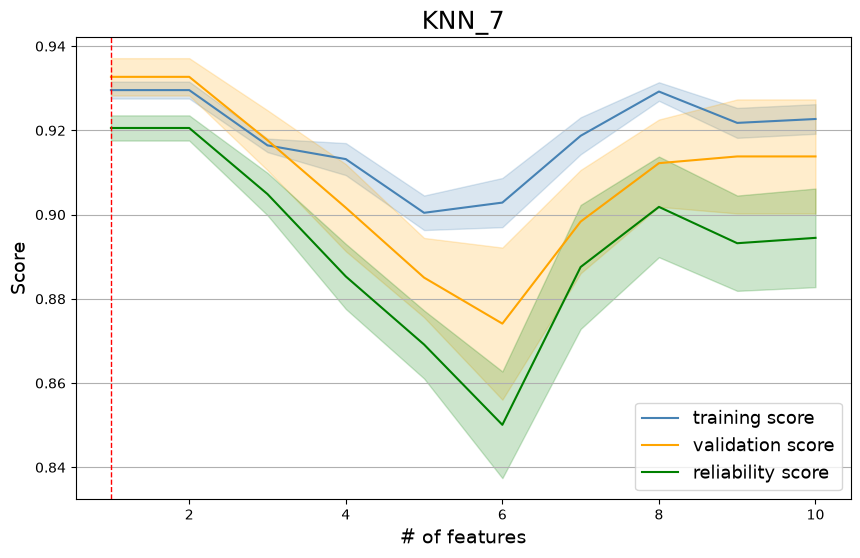

2026-09-30 08:28:07,743 - mlchem.ml.feature_selection.wrappers - INFO - SFS summary: number_of_features=1
2026-09-30 08:28:07,747 - mlchem.ml.feature_selection.wrappers - INFO - SFS summary: winner_subset=['SMR_VSA1']
2026-09-30 08:28:07,751 - mlchem.ml.feature_selection.wrappers - INFO - SFS summary: train_score=0.929567626371264 ± 0.0020050984129192074
2026-09-30 08:28:07,760 - mlchem.ml.feature_selection.wrappers - INFO - SFS summary: cv_score=0.9327163658814606 ± 0.004435629944387021
2026-09-30 08:28:07,769 - mlchem.ml.feature_selection.wrappers - INFO - SFS summary: reliability_score=0.9205751048787263 ± 0.002988071746744683
2026-09-30 08:28:07,824 - mlchem.ml.feature_selection.wrappers - INFO - Combinatorial stage 1 start: samples=535, features=32, k=3, n_jobs=12






-------------




COMBINATORIAL STAGE 1 - COARSE SEARCH


Stage 1: 100%|██████████| 175/175 [01:06<00:00,  2.64it/s]
2026-09-30 08:29:15,368 - mlchem.ml.feature_selection.wrappers - INFO - Combinatorial stage 1 completed: kept_subsets=168


,feature_subsets,training_score,cv_score,reliability_score,training_se,cv_se,reliability_se
1,[SMR_VSA1],0.929568,0.932716,0.920575,0.002005,0.004436,0.002988
15,"[SMR_VSA1, Kappa3]",0.924203,0.914576,0.901450,0.001828,0.009996,0.009796
12,"[SMR_VSA1, EState_VSA2]",0.909307,0.903732,0.894548,0.002650,0.005232,0.005641
11,"[SMR_VSA1, EState_VSA9]",0.915374,0.896817,0.883919,0.001660,0.009591,0.010461
65,"[SMR_VSA1, MaxAbsEStateIndex, MinEStateIndex]",0.914038,0.897506,0.880610,0.002647,0.011031,0.008564


2026-09-30 08:29:15,423 - mlchem.ml.feature_selection.wrappers - INFO - Combinatorial stage 2 start: recurrent_features=6, subset_size=5, n_jobs=12


...

Stage 1: 100%|██████████| 62/62 [00:08<00:00,  7.19it/s]
2026-09-30 08:29:24,533 - mlchem.ml.feature_selection.wrappers - INFO - Combinatorial stage 2 completed: kept_subsets=17


,feature_subsets,training_score,cv_score,reliability_score,training_se,cv_se,reliability_se
0,[SMR_VSA1],0.929568,0.932716,0.920575,0.002005,0.004436,0.002988
4,"[Kappa3, SMR_VSA1]",0.924203,0.914576,0.901450,0.001828,0.009996,0.009796
1,"[EState_VSA9, SMR_VSA1]",0.915374,0.896817,0.883919,0.001660,0.009591,0.010461
12,"[Kappa3, MaxAbsEStateIndex, MinEStateIndex, SM...",0.913657,0.900303,0.880774,0.002755,0.012219,0.009433
9,"[MaxAbsEStateIndex, MinEStateIndex, SMR_VSA1]",0.914038,0.897506,0.880610,0.002647,0.011031,0.008564


2026-09-30 08:29:24,694 - mlchem.ml.feature_selection.wrappers - INFO - SFS start: samples=535, features=32, max_features=10, cv_iter=0, n_jobs=1



KNN_9




SFS: 100%|██████████| 10/10 [01:38<00:00,  9.82s/it]
2026-09-30 08:31:02,957 - mlchem.ml.feature_selection.wrappers - INFO - SFS completed: selected_features=10
2026-09-30 08:31:02,963 - mlchem.ml.feature_selection.wrappers - INFO - SFS parsimony: mode=uncertainty | reference_k*=2 | selected_k=1


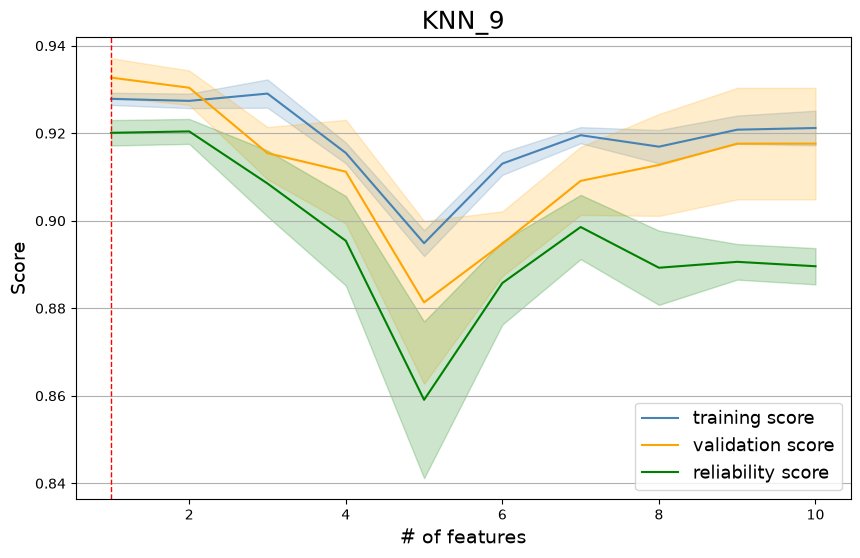

2026-09-30 08:31:04,844 - mlchem.ml.feature_selection.wrappers - INFO - SFS summary: number_of_features=1
2026-09-30 08:31:04,848 - mlchem.ml.feature_selection.wrappers - INFO - SFS summary: winner_subset=['SMR_VSA1']
2026-09-30 08:31:04,852 - mlchem.ml.feature_selection.wrappers - INFO - SFS summary: train_score=0.9278487380635434 ± 0.001395829714829215
2026-09-30 08:31:04,856 - mlchem.ml.feature_selection.wrappers - INFO - SFS summary: cv_score=0.9327163658814606 ± 0.004435629944387021
2026-09-30 08:31:04,860 - mlchem.ml.feature_selection.wrappers - INFO - SFS summary: reliability_score=0.9200926758707768 ± 0.0029075403558748002
2026-09-30 08:31:04,868 - mlchem.ml.feature_selection.wrappers - INFO - Combinatorial stage 1 start: samples=535, features=32, k=3, n_jobs=12






-------------




COMBINATORIAL STAGE 1 - COARSE SEARCH


Stage 1: 100%|██████████| 175/175 [01:38<00:00,  1.78it/s]
2026-09-30 08:32:44,414 - mlchem.ml.feature_selection.wrappers - INFO - Combinatorial stage 1 completed: kept_subsets=167


,feature_subsets,training_score,cv_score,reliability_score,training_se,cv_se,reliability_se
7,[SMR_VSA1],0.927849,0.932716,0.920093,0.001396,0.004436,0.002908
12,"[SMR_VSA1, EState_VSA2]",0.909990,0.907573,0.897044,0.000541,0.006659,0.005632
13,"[SMR_VSA1, Kappa3]",0.920926,0.907654,0.894129,0.000970,0.011616,0.011250
66,"[SMR_VSA1, MaxAbsEStateIndex, MinEStateIndex]",0.911358,0.897735,0.877299,0.002528,0.012195,0.007817
93,"[PEOE_VSA1, MaxAbsEStateIndex, MinEStateIndex]",0.910303,0.896493,0.873591,0.002167,0.016496,0.014051


2026-09-30 08:32:44,515 - mlchem.ml.feature_selection.wrappers - INFO - Combinatorial stage 2 start: recurrent_features=6, subset_size=5, n_jobs=12


COMBINATORIAL STAGE 2 - FINE SEARCH


Stage 1: 100%|██████████| 62/62 [00:06<00:00,  9.82it/s]
2026-09-30 08:32:51,239 - mlchem.ml.feature_selection.wrappers - INFO - Combinatorial stage 2 completed: kept_subsets=12


,feature_subsets,training_score,cv_score,reliability_score,training_se,cv_se,reliability_se
0,[SMR_VSA1],0.927849,0.932716,0.920093,0.001396,0.004436,0.002908
1,"[Kappa3, SMR_VSA1]",0.920926,0.907654,0.894129,0.000970,0.011616,0.011250
9,"[Kappa3, MaxAbsEStateIndex, MinEStateIndex, SM...",0.914465,0.897681,0.880002,0.002109,0.012002,0.010844
5,"[MaxAbsEStateIndex, MinEStateIndex, PEOE_VSA1]",0.910303,0.896493,0.873591,0.002167,0.016496,0.014051
11,"[EState_VSA2, Kappa3, MaxAbsEStateIndex, MinES...",0.905624,0.886985,0.872198,0.002808,0.011481,0.011687


In [25]:
SFS = wrappers.SequentialForwardSelection
metric = roc_auc_score

neighbours = [3, 5, 7, 9]

for n in neighbours:
    estimator = KNeighborsClassifier(n_neighbors=n)
    estimator_string = f'KNN_{n}'
    print('\n%s\n\n' % estimator_string)
    sfs = SFS(
        estimator=estimator,
        estimator_string=estimator_string,
        metric=metric,
        max_features=max_features,
        cv_iter=cv_iter,
        logic='greater',
        task_type='classification',
        log_level='INFO',
        cv_indices=cv_indices,
    )
    sfs.fit(
        train_set=train_set_scaled,
        test_set=test_set_scaled,
        y_train=y_train,
        y_test=y_test,
    )

    features_best_sfs = sfs.find_best(parsimony_mode='uncertainty')['features']
    sfs.plot(title_size=18, title=estimator_string, best_feature=len(features_best_sfs))
    print('\n\n\n\n-------------\n\n\n\n')

    COMB = wrappers.CombinatorialSelection
    comb = COMB(estimator=estimator,metric=metric,logic='greater',
                task_type='classification',
                cv_indices=cv_indices,
                )

    print('COMBINATORIAL STAGE 1 - COARSE SEARCH')
    results_1 = comb.fit_stage_1(train_set=train_set_scaled,
                                test_set=test_set_scaled,
                                y_train=y_train,
                                y_test=y_test,
                                features=train_set_scaled.columns,
                                k=k,
                                training_threshold=training_threshold,
                                max_subsets=None,
                                ranking_target=y_train,
                                top_ranked_features=top_ranked_features,
                                cv_train_ratio=cv_train_ratio,
                                cv_iter=cv_iter,
                                n_jobs=n_jobs,)
    display(results_1.head())
    print('COMBINATORIAL STAGE 2 - FINE SEARCH')
    results_2 = comb.fit_stage_2(top_n_subsets=top_n_subsets,cv_iter=cv_iter,n_jobs=n_jobs)
    display(results_2.head())

   
    fitted_estimator_sfs = estimator.fit(train_set_scaled[features_best_sfs], y_train)
    joblib.dump(fitted_estimator_sfs, f'../data/{estimator_string}_SFS_estimator')
    joblib.dump(features_best_sfs, f'../data/{estimator_string}_SFS_cols')

    if results_2.empty:
        # No subset survived the stage-2 cv_train_ratio/training_threshold filters for this estimator
        print(f'No combinatorial subsets passed the stage-2 filters for {estimator_string}; skipping COMB save.')
    else:
        features_best_comb = results_2['feature_subsets'].values[0]
        fitted_estimator_comb = estimator.fit(train_set_scaled[features_best_comb], y_train)
        joblib.dump(fitted_estimator_comb, f'../data/{estimator_string}_COMB_estimator')
        joblib.dump(features_best_comb, f'../data/{estimator_string}_COMB_cols')

### Logistic Regression

2026-09-30 08:39:06,648 - mlchem.ml.feature_selection.wrappers - INFO - SFS start: samples=535, features=32, max_features=10, cv_iter=0, n_jobs=1



LOGREG_l1ratio_0_C_0.1




SFS:   0%|          | 0/10 [00:00<?, ?it/s]

2026-09-30 08:39:10,049 - mlchem.ml.feature_selection.wrappers - INFO - SFS accepted cycle=1 | feature=MinEStateIndex | cv=0.8054 +- 0.0270
SFS: 100%|██████████| 10/10 [00:21<00:00,  2.13s/it]
2026-09-30 08:39:27,915 - mlchem.ml.feature_selection.wrappers - INFO - SFS completed: selected_features=10
2026-09-30 08:39:27,919 - mlchem.ml.feature_selection.wrappers - INFO - SFS parsimony: mode=uncertainty | reference_k*=10 | selected_k=10


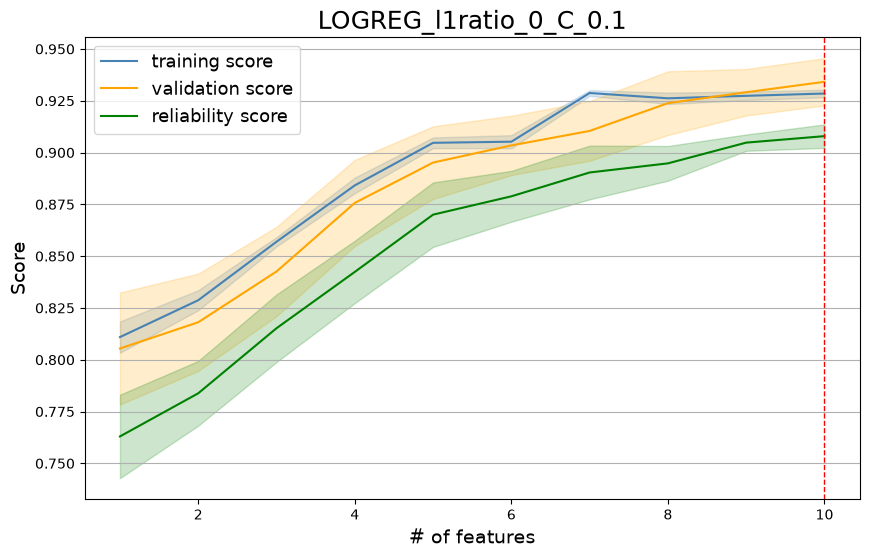

2026-09-30 08:39:30,360 - mlchem.ml.feature_selection.wrappers - INFO - SFS summary: number_of_features=10
2026-09-30 08:39:30,368 - mlchem.ml.feature_selection.wrappers - INFO - SFS summary: winner_subset=['MinEStateIndex', 'VSA_EState2', 'MaxAbsEStateIndex', 'SMR_VSA1', 'fr_Imine', 'EState_VSA2', 'fr_ether', 'SMR_VSA10', 'VSA_EState8', 'fr_NH0']
2026-09-30 08:39:30,372 - mlchem.ml.feature_selection.wrappers - INFO - SFS summary: train_score=0.9284881116841438 ± 0.0018340861042015959
2026-09-30 08:39:30,378 - mlchem.ml.feature_selection.wrappers - INFO - SFS summary: cv_score=0.934153441364052 ± 0.011403832419516416
2026-09-30 08:39:30,382 - mlchem.ml.feature_selection.wrappers - INFO - SFS summary: reliability_score=0.9079201202341196 ± 0.00566232799723603
2026-09-30 08:39:30,394 - mlchem.ml.feature_selection.wrappers - INFO - Combinatorial stage 1 start: samples=535, features=32, k=8, n_jobs=12






-------------




COMBINATORIAL STAGE 1 - COARSE SEARCH


Stage 1: 100%|██████████| 1012/1012 [02:35<00:00,  6.49it/s]
2026-09-30 08:42:07,481 - mlchem.ml.feature_selection.wrappers - INFO - Combinatorial stage 1 completed: kept_subsets=890


,feature_subsets,training_score,cv_score,reliability_score,training_se,cv_se,reliability_se
104,"[MinEStateIndex, Kappa3, qed]",0.817930,0.818435,0.778447,0.002145,0.026071,0.018876
282,"[MinEStateIndex, Kappa3, qed, VSA_EState8]",0.821803,0.808650,0.776987,0.004283,0.028652,0.024206
359,"[SMR_VSA1, EState_VSA9, MinEStateIndex, Kappa3...",0.824077,0.816747,0.774992,0.005181,0.026292,0.016005
139,"[SMR_VSA1, EState_VSA9, MinEStateIndex, qed]",0.822502,0.817980,0.774938,0.004871,0.026429,0.015652
107,"[MinEStateIndex, qed, VSA_EState8]",0.821117,0.807215,0.774098,0.004351,0.028766,0.023892


2026-09-30 08:42:07,534 - mlchem.ml.feature_selection.wrappers - INFO - Combinatorial stage 2 start: recurrent_features=6, subset_size=5, n_jobs=12


...

Stage 1: 100%|██████████| 62/62 [00:04<00:00, 12.90it/s]
2026-09-30 08:42:12,721 - mlchem.ml.feature_selection.wrappers - INFO - Combinatorial stage 2 completed: kept_subsets=25


,feature_subsets,training_score,cv_score,reliability_score,training_se,cv_se,reliability_se
5,"[Kappa3, MinEStateIndex, qed]",0.817930,0.818435,0.778447,0.002145,0.026071,0.018876
19,"[Kappa3, MinEStateIndex, VSA_EState8, qed]",0.821803,0.808650,0.776987,0.004283,0.028652,0.024206
20,"[EState_VSA9, Kappa3, MinEStateIndex, SMR_VSA1...",0.824077,0.816747,0.774992,0.005181,0.026292,0.016005
15,"[EState_VSA9, MinEStateIndex, SMR_VSA1, qed]",0.822502,0.817980,0.774938,0.004871,0.026429,0.015652
12,"[MinEStateIndex, VSA_EState8, qed]",0.821117,0.807215,0.774098,0.004351,0.028766,0.023892


2026-09-30 08:42:12,854 - mlchem.ml.feature_selection.wrappers - INFO - SFS start: samples=535, features=32, max_features=10, cv_iter=0, n_jobs=1



LOGREG_l1ratio_0_C_1.0




SFS: 100%|██████████| 10/10 [00:29<00:00,  2.98s/it]
2026-09-30 08:42:42,688 - mlchem.ml.feature_selection.wrappers - INFO - SFS completed: selected_features=10
2026-09-30 08:42:42,692 - mlchem.ml.feature_selection.wrappers - INFO - SFS parsimony: mode=uncertainty | reference_k*=10 | selected_k=6


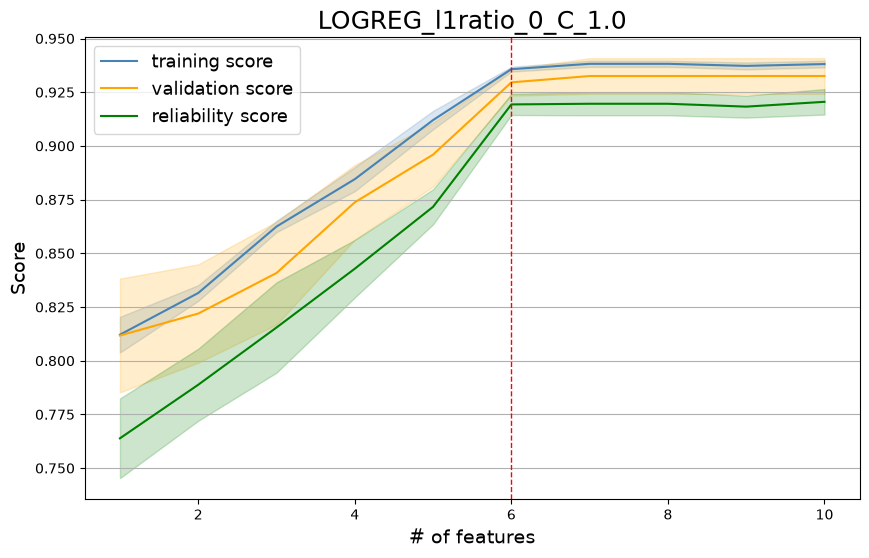

2026-09-30 08:42:43,861 - mlchem.ml.feature_selection.wrappers - INFO - SFS summary: number_of_features=6
2026-09-30 08:42:43,870 - mlchem.ml.feature_selection.wrappers - INFO - SFS summary: winner_subset=['MinEStateIndex', 'VSA_EState2', 'MaxAbsEStateIndex', 'SMR_VSA1', 'fr_ether', 'fr_Imine']
2026-09-30 08:42:43,874 - mlchem.ml.feature_selection.wrappers - INFO - SFS summary: train_score=0.9357340114053241 ± 0.001111135304389443
2026-09-30 08:42:43,878 - mlchem.ml.feature_selection.wrappers - INFO - SFS summary: cv_score=0.9295907393457714 ± 0.006174670127360633
2026-09-30 08:42:43,886 - mlchem.ml.feature_selection.wrappers - INFO - SFS summary: reliability_score=0.9193213921173891 ± 0.004944848444580881
2026-09-30 08:42:43,897 - mlchem.ml.feature_selection.wrappers - INFO - Combinatorial stage 1 start: samples=535, features=32, k=8, n_jobs=12






-------------




COMBINATORIAL STAGE 1 - COARSE SEARCH


Stage 1: 100%|██████████| 1012/1012 [03:06<00:00,  5.44it/s]
2026-09-30 08:45:51,066 - mlchem.ml.feature_selection.wrappers - INFO - Combinatorial stage 1 completed: kept_subsets=901


,feature_subsets,training_score,cv_score,reliability_score,training_se,cv_se,reliability_se
507,"[EState_VSA9, MinEStateIndex, Kappa3, qed, VSA...",0.842151,0.828830,0.792514,0.003440,0.026369,0.020696
290,"[MinEStateIndex, Kappa3, qed, VSA_EState8]",0.831857,0.818353,0.785796,0.003207,0.025562,0.021558
103,"[MinEStateIndex, Kappa3, qed]",0.824803,0.818037,0.782475,0.003589,0.025972,0.020083
631,"[SMR_VSA1, EState_VSA9, MinEStateIndex, Kappa3...",0.837743,0.820106,0.781105,0.005869,0.027760,0.020242
254,"[EState_VSA9, MinEStateIndex, qed, VSA_EState8]",0.828873,0.824987,0.778906,0.004889,0.026739,0.017663


2026-09-30 08:45:51,136 - mlchem.ml.feature_selection.wrappers - INFO - Combinatorial stage 2 start: recurrent_features=6, subset_size=5, n_jobs=12


...

Stage 1: 100%|██████████| 62/62 [00:04<00:00, 12.82it/s]
2026-09-30 08:45:56,545 - mlchem.ml.feature_selection.wrappers - INFO - Combinatorial stage 2 completed: kept_subsets=23


,feature_subsets,training_score,cv_score,reliability_score,training_se,cv_se,reliability_se
18,"[EState_VSA9, Kappa3, MinEStateIndex, VSA_ESta...",0.842151,0.828830,0.792514,0.003440,0.026369,0.020696
19,"[Kappa3, MinEStateIndex, VSA_EState8, qed]",0.831857,0.818353,0.785796,0.003207,0.025562,0.021558
6,"[Kappa3, MinEStateIndex, qed]",0.824803,0.818037,0.782475,0.003589,0.025972,0.020083
13,"[EState_VSA9, MinEStateIndex, VSA_EState8, qed]",0.828873,0.824987,0.778906,0.004889,0.026739,0.017663
17,"[Kappa3, MinEStateIndex, SMR_VSA1, qed]",0.831587,0.822450,0.778541,0.005775,0.028223,0.018178


2026-09-30 08:45:56,692 - mlchem.ml.feature_selection.wrappers - INFO - SFS start: samples=535, features=32, max_features=10, cv_iter=0, n_jobs=1



LOGREG_l1ratio_0_C_10.0




SFS: 100%|██████████| 10/10 [00:32<00:00,  3.26s/it]
2026-09-30 08:46:29,359 - mlchem.ml.feature_selection.wrappers - INFO - SFS completed: selected_features=10
2026-09-30 08:46:29,366 - mlchem.ml.feature_selection.wrappers - INFO - SFS parsimony: mode=uncertainty | reference_k*=8 | selected_k=6


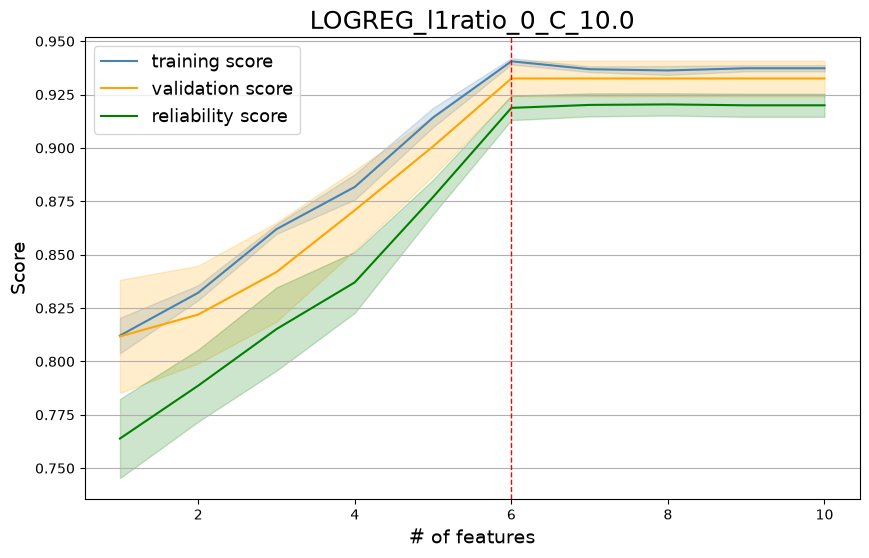

2026-09-30 08:46:30,993 - mlchem.ml.feature_selection.wrappers - INFO - SFS summary: number_of_features=6
2026-09-30 08:46:30,996 - mlchem.ml.feature_selection.wrappers - INFO - SFS summary: winner_subset=['MinEStateIndex', 'VSA_EState2', 'MaxAbsEStateIndex', 'SMR_VSA1', 'fr_ether', 'fr_Imine']
2026-09-30 08:46:30,999 - mlchem.ml.feature_selection.wrappers - INFO - SFS summary: train_score=0.9405883123807228 ± 0.0014690285032968738
2026-09-30 08:46:31,002 - mlchem.ml.feature_selection.wrappers - INFO - SFS summary: cv_score=0.9325367560748046 ± 0.008316244871729958
2026-09-30 08:46:31,004 - mlchem.ml.feature_selection.wrappers - INFO - SFS summary: reliability_score=0.9187734400069048 ± 0.005750989662166172
2026-09-30 08:46:31,014 - mlchem.ml.feature_selection.wrappers - INFO - Combinatorial stage 1 start: samples=535, features=32, k=8, n_jobs=12






-------------




COMBINATORIAL STAGE 1 - COARSE SEARCH


Stage 1: 100%|██████████| 1012/1012 [03:15<00:00,  5.17it/s]
2026-09-30 08:49:47,895 - mlchem.ml.feature_selection.wrappers - INFO - Combinatorial stage 1 completed: kept_subsets=901


,feature_subsets,training_score,cv_score,reliability_score,training_se,cv_se,reliability_se
410,"[SMR_VSA1, MinEStateIndex, Kappa3, qed, VSA_ES...",0.844044,0.822021,0.787141,0.003171,0.026788,0.018240
362,"[SMR_VSA1, EState_VSA9, MinEStateIndex, Kappa3...",0.833371,0.814110,0.783932,0.005360,0.025136,0.020079
630,"[SMR_VSA1, EState_VSA9, MinEStateIndex, Kappa3...",0.842896,0.819359,0.783526,0.003961,0.027488,0.019177
249,"[EState_VSA9, MinEStateIndex, Kappa3, qed]",0.835042,0.822879,0.781973,0.005537,0.030069,0.019567
506,"[EState_VSA9, MinEStateIndex, Kappa3, qed, VSA...",0.841757,0.830071,0.781826,0.005333,0.031162,0.017892


2026-09-30 08:49:48,042 - mlchem.ml.feature_selection.wrappers - INFO - Combinatorial stage 2 start: recurrent_features=6, subset_size=5, n_jobs=12


...

Stage 1: 100%|██████████| 62/62 [00:02<00:00, 26.13it/s] 
2026-09-30 08:49:51,017 - mlchem.ml.feature_selection.wrappers - INFO - Combinatorial stage 2 completed: kept_subsets=8


,feature_subsets,training_score,cv_score,reliability_score,training_se,cv_se,reliability_se
5,"[Kappa3, MinEStateIndex, SMR_VSA1, VSA_EState8...",0.844044,0.822021,0.787141,0.003171,0.026788,0.018240
3,"[EState_VSA9, Kappa3, MinEStateIndex, qed]",0.835042,0.822879,0.781973,0.005537,0.030069,0.019567
7,"[EState_VSA9, Kappa3, MinEStateIndex, VSA_ESta...",0.841757,0.830071,0.781826,0.005333,0.031162,0.017892
4,"[EState_VSA9, MinEStateIndex, VSA_EState8, qed]",0.829374,0.822254,0.776310,0.004593,0.027640,0.018437
6,"[Kappa3, MinEStateIndex, VSA_EState8, qed]",0.830807,0.808025,0.774227,0.003729,0.028912,0.022299


2026-09-30 08:49:51,221 - mlchem.ml.feature_selection.wrappers - INFO - SFS start: samples=535, features=32, max_features=10, cv_iter=0, n_jobs=1



LOGREG_l1ratio_1_C_0.1




SFS: 100%|██████████| 10/10 [00:31<00:00,  3.16s/it]
2026-09-30 08:50:22,858 - mlchem.ml.feature_selection.wrappers - INFO - SFS completed: selected_features=10
2026-09-30 08:50:22,862 - mlchem.ml.feature_selection.wrappers - INFO - SFS parsimony: mode=uncertainty | reference_k*=6 | selected_k=6


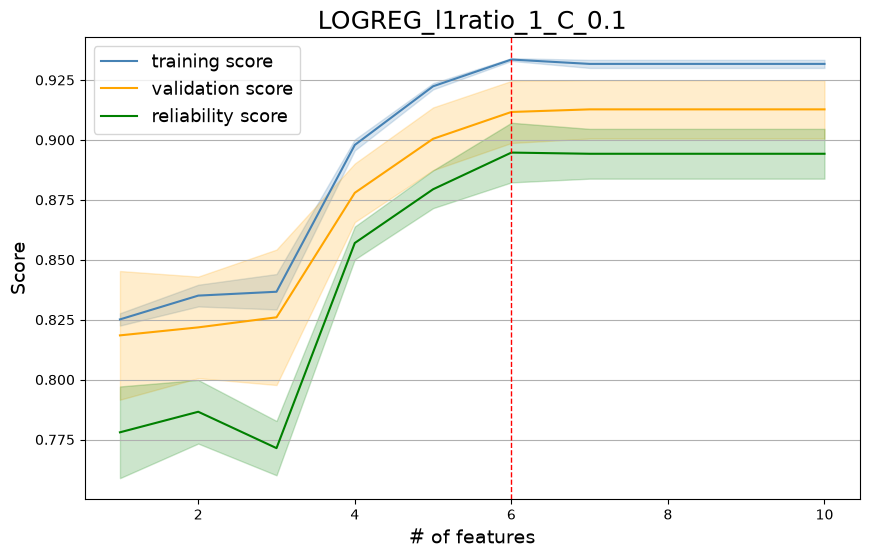

2026-09-30 08:50:25,082 - mlchem.ml.feature_selection.wrappers - INFO - SFS summary: number_of_features=6
2026-09-30 08:50:25,086 - mlchem.ml.feature_selection.wrappers - INFO - SFS summary: winner_subset=['MinEStateIndex', 'VSA_EState2', 'SMR_VSA1', 'fr_ether', 'fr_Imine', 'MaxAbsEStateIndex']
2026-09-30 08:50:25,090 - mlchem.ml.feature_selection.wrappers - INFO - SFS summary: train_score=0.9335342792242184 ± 0.0005798741180591536
2026-09-30 08:50:25,092 - mlchem.ml.feature_selection.wrappers - INFO - SFS summary: cv_score=0.9116604057189832 ± 0.012939305379675154
2026-09-30 08:50:25,096 - mlchem.ml.feature_selection.wrappers - INFO - SFS summary: reliability_score=0.8947209692574157 ± 0.012444168531569603
2026-09-30 08:50:25,110 - mlchem.ml.feature_selection.wrappers - INFO - Combinatorial stage 1 start: samples=535, features=32, k=8, n_jobs=12






-------------




COMBINATORIAL STAGE 1 - COARSE SEARCH


Stage 1: 100%|██████████| 1012/1012 [02:01<00:00,  8.35it/s]
2026-09-30 08:52:27,703 - mlchem.ml.feature_selection.wrappers - INFO - Combinatorial stage 1 completed: kept_subsets=879


,feature_subsets,training_score,cv_score,reliability_score,training_se,cv_se,reliability_se
75,"[EState_VSA9, MinEStateIndex, qed]",0.843103,0.823801,0.790536,0.002753,0.028554,0.024323
244,"[EState_VSA9, MinEStateIndex, Kappa3, qed]",0.843103,0.823801,0.790536,0.002753,0.028554,0.024323
243,"[EState_VSA9, MinEStateIndex, qed, VSA_EState8]",0.840078,0.827889,0.789648,0.003661,0.026594,0.020724
492,"[EState_VSA9, MinEStateIndex, Kappa3, qed, VSA...",0.840078,0.827889,0.789648,0.003661,0.026594,0.020724
78,"[EState_VSA9, MinEStateIndex, Kappa3]",0.831277,0.818411,0.787723,0.003260,0.026123,0.021785


2026-09-30 08:52:27,721 - mlchem.ml.feature_selection.wrappers - INFO - Combinatorial stage 2 start: recurrent_features=5, subset_size=5, n_jobs=12


...

Stage 1: 100%|██████████| 31/31 [00:00<00:00, 37.91it/s] 
2026-09-30 08:52:28,698 - mlchem.ml.feature_selection.wrappers - INFO - Combinatorial stage 2 completed: kept_subsets=8


,feature_subsets,training_score,cv_score,reliability_score,training_se,cv_se,reliability_se
3,"[EState_VSA9, MinEStateIndex, qed]",0.843103,0.823801,0.790536,0.002753,0.028554,0.024323
2,"[EState_VSA9, Kappa3, MinEStateIndex, qed]",0.843103,0.823801,0.790536,0.002753,0.028554,0.024323
6,"[EState_VSA9, Kappa3, MinEStateIndex, VSA_ESta...",0.840078,0.827889,0.789648,0.003661,0.026594,0.020724
4,"[EState_VSA9, MinEStateIndex, VSA_EState8, qed]",0.840078,0.827889,0.789648,0.003661,0.026594,0.020724
0,"[EState_VSA9, MinEStateIndex]",0.831277,0.818411,0.787723,0.003260,0.026123,0.021785


2026-09-30 08:52:28,761 - mlchem.ml.feature_selection.wrappers - INFO - SFS start: samples=535, features=32, max_features=10, cv_iter=0, n_jobs=1



LOGREG_l1ratio_1_C_1.0




SFS: 100%|██████████| 10/10 [00:25<00:00,  2.59s/it]
2026-09-30 08:52:54,695 - mlchem.ml.feature_selection.wrappers - INFO - SFS completed: selected_features=10
2026-09-30 08:52:54,699 - mlchem.ml.feature_selection.wrappers - INFO - SFS parsimony: mode=uncertainty | reference_k*=9 | selected_k=7


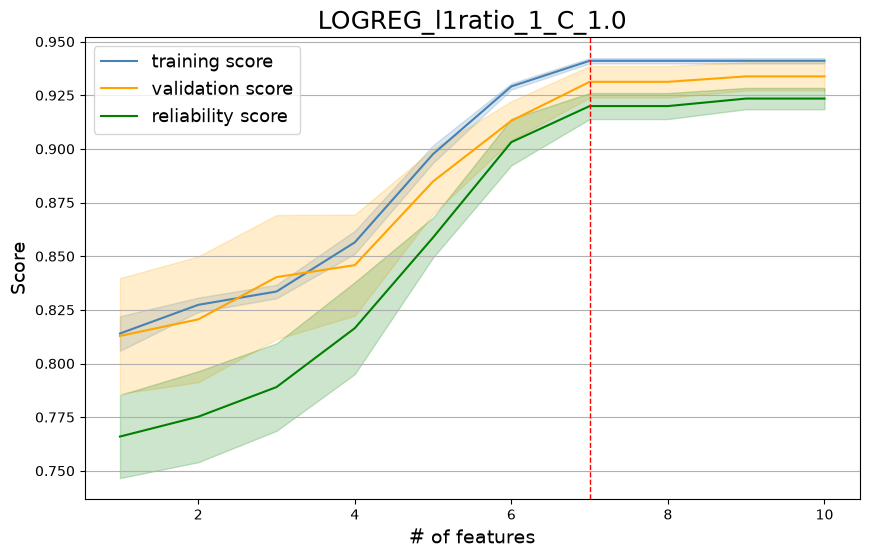

2026-09-30 08:52:55,886 - mlchem.ml.feature_selection.wrappers - INFO - SFS summary: number_of_features=7
2026-09-30 08:52:55,889 - mlchem.ml.feature_selection.wrappers - INFO - SFS summary: winner_subset=['MinEStateIndex', 'HallKierAlpha', 'SMR_VSA1', 'fr_ether', 'VSA_EState2', 'fr_Imine', 'MaxAbsEStateIndex']
2026-09-30 08:52:55,893 - mlchem.ml.feature_selection.wrappers - INFO - SFS summary: train_score=0.941070288276844 ± 0.0012267529671678853
2026-09-30 08:52:55,899 - mlchem.ml.feature_selection.wrappers - INFO - SFS summary: cv_score=0.9312797214282398 ± 0.007363411075170791
2026-09-30 08:52:55,900 - mlchem.ml.feature_selection.wrappers - INFO - SFS summary: reliability_score=0.9199692788988159 ± 0.006064946605053897
2026-09-30 08:52:55,911 - mlchem.ml.feature_selection.wrappers - INFO - Combinatorial stage 1 start: samples=535, features=32, k=8, n_jobs=12






-------------




COMBINATORIAL STAGE 1 - COARSE SEARCH


Stage 1: 100%|██████████| 1012/1012 [01:44<00:00,  9.67it/s]
2026-09-30 08:54:41,404 - mlchem.ml.feature_selection.wrappers - INFO - Combinatorial stage 1 completed: kept_subsets=896


,feature_subsets,training_score,cv_score,reliability_score,training_se,cv_se,reliability_se
502,"[EState_VSA9, MinEStateIndex, Kappa3, qed, VSA...",0.846413,0.824975,0.787901,0.004155,0.028334,0.019924
402,"[SMR_VSA1, MinEStateIndex, Kappa3, qed, VSA_ES...",0.845283,0.822021,0.787620,0.004132,0.026788,0.018394
622,"[SMR_VSA1, EState_VSA9, MinEStateIndex, Kappa3...",0.847051,0.820466,0.786523,0.004516,0.026580,0.020032
362,"[SMR_VSA1, EState_VSA9, MinEStateIndex, Kappa3...",0.834684,0.819202,0.782632,0.003868,0.029068,0.021561
109,"[MinEStateIndex, Kappa3, qed]",0.826649,0.807342,0.781044,0.002865,0.024565,0.020178


2026-09-30 08:54:41,451 - mlchem.ml.feature_selection.wrappers - INFO - Combinatorial stage 2 start: recurrent_features=6, subset_size=5, n_jobs=12


...

Stage 1: 100%|██████████| 62/62 [00:03<00:00, 19.12it/s]
2026-09-30 08:54:44,958 - mlchem.ml.feature_selection.wrappers - INFO - Combinatorial stage 2 completed: kept_subsets=20


,feature_subsets,training_score,cv_score,reliability_score,training_se,cv_se,reliability_se
17,"[EState_VSA9, Kappa3, MinEStateIndex, VSA_ESta...",0.846413,0.824975,0.787901,0.004155,0.028334,0.019924
18,"[Kappa3, MinEStateIndex, SMR_VSA1, VSA_EState8...",0.845283,0.822021,0.787620,0.004132,0.026788,0.018394
16,"[EState_VSA9, Kappa3, MinEStateIndex, SMR_VSA1...",0.834684,0.819202,0.782632,0.003868,0.029068,0.021561
8,"[Kappa3, MinEStateIndex, qed]",0.826649,0.807342,0.781044,0.002865,0.024565,0.020178
15,"[Kappa3, MinEStateIndex, SMR_VSA1, qed]",0.832083,0.821312,0.780405,0.005866,0.028745,0.018486


2026-09-30 08:54:45,062 - mlchem.ml.feature_selection.wrappers - INFO - SFS start: samples=535, features=32, max_features=10, cv_iter=0, n_jobs=1



LOGREG_l1ratio_1_C_10.0




SFS: 100%|██████████| 10/10 [00:26<00:00,  2.68s/it]
2026-09-30 08:55:11,910 - mlchem.ml.feature_selection.wrappers - INFO - SFS completed: selected_features=10
2026-09-30 08:55:11,910 - mlchem.ml.feature_selection.wrappers - INFO - SFS parsimony: mode=uncertainty | reference_k*=7 | selected_k=6


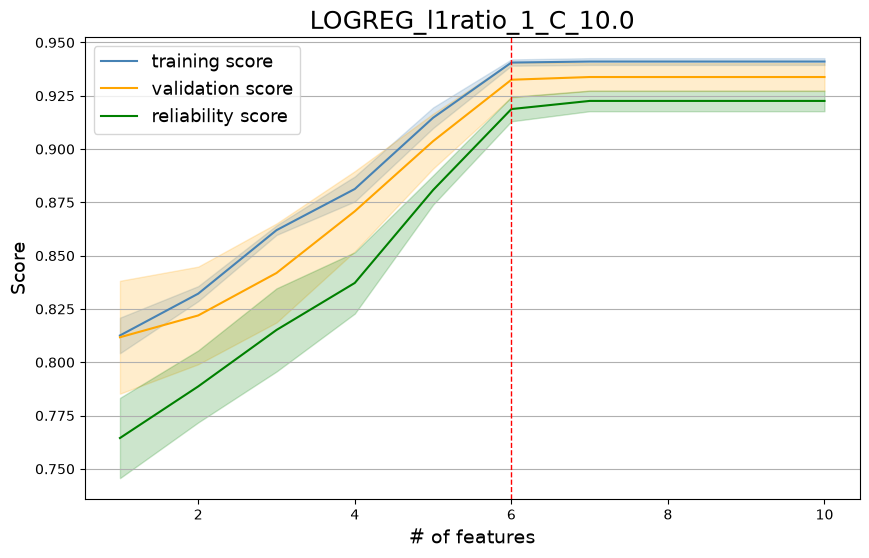

2026-09-30 08:55:13,082 - mlchem.ml.feature_selection.wrappers - INFO - SFS summary: number_of_features=6
2026-09-30 08:55:13,087 - mlchem.ml.feature_selection.wrappers - INFO - SFS summary: winner_subset=['MinEStateIndex', 'VSA_EState2', 'MaxAbsEStateIndex', 'SMR_VSA1', 'fr_ether', 'fr_Imine']
2026-09-30 08:55:13,100 - mlchem.ml.feature_selection.wrappers - INFO - SFS summary: train_score=0.9405883123807228 ± 0.0014690285032968738
2026-09-30 08:55:13,114 - mlchem.ml.feature_selection.wrappers - INFO - SFS summary: cv_score=0.9325367560748046 ± 0.008316244871729958
2026-09-30 08:55:13,125 - mlchem.ml.feature_selection.wrappers - INFO - SFS summary: reliability_score=0.9187734400069048 ± 0.005750989662166172
2026-09-30 08:55:13,173 - mlchem.ml.feature_selection.wrappers - INFO - Combinatorial stage 1 start: samples=535, features=32, k=8, n_jobs=12






-------------




COMBINATORIAL STAGE 1 - COARSE SEARCH


Stage 1: 100%|██████████| 1012/1012 [02:06<00:00,  7.97it/s]
2026-09-30 08:57:20,991 - mlchem.ml.feature_selection.wrappers - INFO - Combinatorial stage 1 completed: kept_subsets=900


,feature_subsets,training_score,cv_score,reliability_score,training_se,cv_se,reliability_se
406,"[SMR_VSA1, MinEStateIndex, Kappa3, qed, VSA_ES...",0.838580,0.817023,0.784135,0.003561,0.025046,0.017211
813,"[SMR_VSA1, EState_VSA9, MinEStateIndex, EState...",0.833632,0.816732,0.783824,0.005796,0.021836,0.016853
652,"[SMR_VSA1, MinEStateIndex, EState_VSA2, Kappa3...",0.832674,0.814762,0.782605,0.004936,0.022168,0.016972
527,"[MinEStateIndex, EState_VSA2, Kappa3, qed, VSA...",0.823700,0.803208,0.781992,0.005261,0.018005,0.017007
250,"[EState_VSA9, MinEStateIndex, Kappa3, qed]",0.829531,0.817126,0.779782,0.006276,0.029122,0.019662


2026-09-30 08:57:21,031 - mlchem.ml.feature_selection.wrappers - INFO - Combinatorial stage 2 start: recurrent_features=7, subset_size=5, n_jobs=12


COMBINATORIAL STAGE 2 - FINE SEARCH


Stage 1: 100%|██████████| 119/119 [00:04<00:00, 25.46it/s]
2026-09-30 08:57:25,993 - mlchem.ml.feature_selection.wrappers - INFO - Combinatorial stage 2 completed: kept_subsets=26


,feature_subsets,training_score,cv_score,reliability_score,training_se,cv_se,reliability_se
25,"[Kappa3, MinEStateIndex, SMR_VSA1, VSA_EState8...",0.838580,0.817023,0.784135,0.003561,0.025046,0.017211
20,"[EState_VSA2, Kappa3, MinEStateIndex, VSA_ESta...",0.823700,0.803208,0.781992,0.005261,0.018005,0.017007
12,"[EState_VSA9, Kappa3, MinEStateIndex, qed]",0.829531,0.817126,0.779782,0.006276,0.029122,0.019662
10,"[MinEStateIndex, VSA_EState8, qed]",0.820612,0.809859,0.778266,0.004653,0.024696,0.019893
24,"[EState_VSA9, Kappa3, MinEStateIndex, VSA_ESta...",0.837356,0.819597,0.778082,0.005394,0.029064,0.017964


In [27]:
SFS = wrappers.SequentialForwardSelection
metric = get_geometric_S

params = generate_cartesian_product([0,1],
                                    [1e-1,1e0,1e1])

for hyperparameter_list in params:
    estimator = LogisticRegression(l1_ratio=hyperparameter_list[0], C=hyperparameter_list[1], solver='liblinear', random_state=1)
    estimator_string = f'LOGREG_l1ratio_{hyperparameter_list[0]}_C_{hyperparameter_list[1]}'
    print('\n%s\n\n' % estimator_string)
    sfs = SFS(
        estimator=estimator,
        estimator_string=estimator_string,
        metric=metric,
        max_features=max_features,
        cv_iter=cv_iter,
        logic='greater',
        task_type='classification',
        log_level='INFO',
        cv_indices=cv_indices,
    )
    sfs.fit(
        train_set=train_set_scaled,
        test_set=test_set_scaled,
        y_train=y_train,
        y_test=y_test,
    )
    features_best_sfs = sfs.find_best(parsimony_mode='uncertainty')['features']
    sfs.plot(title_size=18, title=estimator_string, best_feature=len(features_best_sfs))
    print('\n\n\n\n-------------\n\n\n\n')

    COMB = wrappers.CombinatorialSelection
    comb = COMB(estimator=estimator,metric=get_geometric_S,logic='greater',
                task_type='classification',cv_indices=cv_indices)

    print('COMBINATORIAL STAGE 1 - COARSE SEARCH')
    results_1 = comb.fit_stage_1(train_set=train_set_scaled,
                                test_set=test_set_scaled,
                                y_train=y_train,
                                y_test=y_test,
                                features=train_set_scaled.columns,
                                k=k,
                                training_threshold=training_threshold,
                                max_subsets=None,
                                ranking_target=y_train,
                                top_ranked_features=top_ranked_features,
                                cv_train_ratio=cv_train_ratio,
                                cv_iter=cv_iter,
                                n_jobs=n_jobs,)
    display(results_1.head())
    print('COMBINATORIAL STAGE 2 - FINE SEARCH')
    results_2 = comb.fit_stage_2(top_n_subsets=top_n_subsets,cv_iter=cv_iter,n_jobs=-1)
    display(results_2.head())

    fitted_estimator_sfs = estimator.fit(train_set_scaled[features_best_sfs], y_train)
    joblib.dump(fitted_estimator_sfs, f'../data/{estimator_string}_SFS_estimator')
    joblib.dump(features_best_sfs, f'../data/{estimator_string}_SFS_cols')

    if results_2.empty:
        # No subset survived the stage-2 cv_train_ratio/training_threshold filters for this estimator
        print(f'No combinatorial subsets passed the stage-2 filters for {estimator_string}; skipping COMB save.')
    else:
        features_best_comb = results_2['feature_subsets'].values[0]
        fitted_estimator_comb = estimator.fit(train_set_scaled[features_best_comb], y_train)
        joblib.dump(fitted_estimator_comb, f'../data/{estimator_string}_COMB_estimator')
        joblib.dump(features_best_comb, f'../data/{estimator_string}_COMB_cols')